# Demo F: vLLM Engine Benchmarks

**Platform:** Lightning.ai Studio (A100 GPU)

**Goal:** Prove that vLLM with optimizations gives 10-20x improvement over HuggingFace.
Same model, same GPU, different flags.

| Experiment | Optimization | vLLM Flag | Expected Gain |
|---|---|---|---|
| 0 | KV Cache Visualization | (default) | See the problem |
| 1 | HF Baseline | (no engine) | 1x |
| 2 | PagedAttention + Batching | (vLLM default) | 5-10x throughput |
| 3 | Prefix Caching | `--enable-prefix-caching` | 5-15x TTFT |
| 4 | KV Quantization | `--kv-cache-dtype fp8` | 2x capacity |
| 5 | Speculative Decoding | `--speculative-model` | 2-3x decode |

## Setup on Lightning.ai:
1. Create a Studio with A100 GPU
2. Install: `pip install vllm openai`
3. Install: `pip install "numpy==1.26.4" --force-reinstall --no-deps`
4. Install: `pip install "scipy==1.18.0" --force-reinstall --no-deps`
5. Download model: `hf download mistralai/Mistral-7B-v0.1`
6. Start vLLM server in terminal (commands provided per experiment)
7. Run this notebook top to bottom


In [4]:
# --- Setup: All imports + utilities (run once) ---
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'openai', 'transformers', 'accelerate'])

import torch, time, requests, re, threading, gc
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from openai import OpenAI
from concurrent.futures import ThreadPoolExecutor, as_completed
from transformers import AutoTokenizer, AutoModelForCausalLM

# ─── Config ───
MODEL = 'mistralai/Mistral-7B-v0.1'
PORT = 8000
VLLM_URL = f'http://localhost:{PORT}'
BASE_URL = f'{VLLM_URL}/v1'
N_REQUESTS = 10
N_TOKENS = 50

client = OpenAI(base_url=BASE_URL, api_key='unused')

# Test prompts (same across ALL experiments)
PROMPTS = [
    'Explain the concept of attention mechanisms in transformers',
    'What are the key differences between CPU and GPU architectures',
    'Describe how PagedAttention works in vLLM',
    'What is the roofline model for GPU performance analysis',
    'Explain continuous batching in LLM serving systems',
    'How does speculative decoding accelerate inference',
    'What are the tradeoffs of KV cache quantization',
    'Describe the prefill vs decode phases of LLM inference',
    'How do mixture of experts models reduce compute costs',
    'What is tensor parallelism and when should you use it',
]

# ─── Utilities ───
def check_server():
    try:
        r = requests.get(f'{VLLM_URL}/health', timeout=3)
        if r.status_code == 200:
            print(f'vLLM server running.')
            return True
    except: pass
    print('vLLM server NOT running.')
    return False

def get_vllm_kv_gb():
    """Get KV cache usage in GB from vLLM /metrics endpoint."""
    try:
        r = requests.get(f'{SERVER_URL}/metrics', timeout=2)
        usage_pct = 0.0
        total_blocks = 0
        block_size = 16  # default vLLM block size in tokens
        for line in r.text.split('\n'):
            if 'kv_cache_usage_perc' in line and not line.startswith('#'):
                usage_pct = float(line.split()[-1])
            if 'gpu_cache_blocks' in line and 'total' in line and not line.startswith('#'):
                total_blocks = float(line.split()[-1])
        # KV per block = 2 * n_layers * head_dim * n_kv_heads * 2bytes * block_size
        # Mistral-7B: 2 * 32 * 128 * 8 * 2 * 16 = 2,097,152 bytes per block = 2MB
        kv_per_block_bytes = 2 * 32 * 128 * 8 * 2 * block_size
        if total_blocks > 0:
            used_blocks = usage_pct * total_blocks
            return (used_blocks * kv_per_block_bytes) / 1e6
        else:
            # Fallback: estimate from percentage of gpu_memory_utilization pool
            pool_gb = 0.9 * 80  # default
            return usage_pct * pool_gb * 1000
    except:
        return 0.0

def warmup_server(n=5):
    """Send warmup requests to compile CUDA graphs."""
    for i in range(n):
        requests.post(f'{BASE_URL}/completions',
            json={'model': MODEL, 'prompt': f'Warmup {i}', 'max_tokens': 20})
    print(f'Warmup done ({n} requests).')

def get_vllm_metrics():
    """Scrape vLLM /metrics endpoint, return dict of metric_name: value."""
    r = requests.get(f'{VLLM_URL}/metrics')
    metrics = {}
    for line in r.text.split('\n'):
        if line and not line.startswith('#'):
            parts = line.split()
            if len(parts) >= 2:
                try:
                    metrics[parts[0]] = float(parts[-1])
                except ValueError:
                    pass
    return metrics

def benchmark_full(prompts, max_tokens=50, n_workers=10, label=''):
    """Full benchmark: throughput, TTFT, ITL. Returns metrics dict."""
    def single_request(prompt):
        t0 = time.perf_counter()
        first_token_time = None
        last_token_time = None
        tokens = 0
        stream = client.completions.create(
            model=MODEL, prompt=prompt, max_tokens=max_tokens,
            temperature=0, stream=True
        )
        for chunk in stream:
            now = time.perf_counter()
            if first_token_time is None:
                first_token_time = now
            last_token_time = now
            tokens += 1
        ttft = (first_token_time - t0) if first_token_time else 0
        # ITL = time between first and last token / (tokens - 1)
        if tokens > 1 and first_token_time and last_token_time:
            itl = (last_token_time - first_token_time) / (tokens - 1)
        else:
            itl = 0
        return {'ttft': ttft, 'itl': itl, 'tokens': tokens}

    t_wall = time.perf_counter()
    with ThreadPoolExecutor(max_workers=n_workers) as pool:
        futures = [pool.submit(single_request, p) for p in prompts]
        req_results = [f.result() for f in tqdm(as_completed(futures), total=len(prompts), desc=label)]
    wall_time = time.perf_counter() - t_wall

    total_tokens = sum(r['tokens'] for r in req_results)
    throughput = total_tokens / wall_time
    avg_ttft = np.mean([r['ttft'] for r in req_results])
    avg_itl = np.mean([r['itl'] for r in req_results])

    print(f'  [{label}] {throughput:.0f} tok/s | TTFT: {avg_ttft*1000:.0f}ms | ITL: {avg_itl*1000:.1f}ms')
    return {'throughput': throughput, 'ttft': avg_ttft, 'itl': avg_itl,
            'wall_time': wall_time, 'total_tokens': total_tokens}



def measure_kv_vs_users(user_counts=[1, 5, 10, 15, 20], max_tokens=1000):
    """KV cache % at different concurrency. Long generation keeps requests alive."""
    kv_data = []
    for n in tqdm(user_counts, desc='KV vs users'):
        prompts_kv = [f'Write a very detailed long essay about topic {i}. Include many examples:' for i in range(n)]
        peak = 0.0
        def send():
            with ThreadPoolExecutor(max_workers=n) as pool:
                futs = [pool.submit(requests.post, f'{BASE_URL}/completions',
                    json={'model': MODEL, 'prompt': p, 'max_tokens': max_tokens, 'temperature': 0.7}
                ) for p in prompts_kv]
                [f.result() for f in futs]
        t = threading.Thread(target=send)
        t.start()
        time.sleep(0.3)
        for _ in range(20):
            m = get_vllm_metrics()
            for k, v in m.items():
                if 'kv_cache_usage_perc' in k:
                    peak = max(peak, v * 100)
            time.sleep(0.5)
        t.join()
        kv_data.append((n, peak))
        print(f'  {n:>3} users -> {peak:.1f}% KV')
    return kv_data

def measure_kv_vs_context(context_lengths=[256, 512, 1024, 2048, 4096], n_users=5, max_tokens=500):
    """Measure KV cache growth at different prompt lengths."""
    kv_data = []
    for ctx_len in tqdm(context_lengths, desc='KV vs context'):
        prompt = ('The quick brown fox jumps over the lazy dog. ' * (ctx_len // 10))[:ctx_len*4]
        prompts_ctx = [prompt + f' Question {i}: explain.' for i in range(n_users)]
        peak_kv = 0.0
        def send():
            with ThreadPoolExecutor(max_workers=n_users) as pool:
                futs = [pool.submit(requests.post, f'{BASE_URL}/completions',
                    json={'model': MODEL, 'prompt': p, 'max_tokens': max_tokens, 'temperature': 0}
                ) for p in prompts_ctx]
                [f.result() for f in futs]
        t = threading.Thread(target=send)
        t.start()
        time.sleep(0.5)
        for _ in range(10):
            m = get_vllm_metrics()
            for k, v in m.items():
                if 'kv_cache_usage_perc' in k:
                    peak_kv = max(peak_kv, v * 100)
            time.sleep(0.3)
        t.join()
        kv_data.append((ctx_len, peak_kv))
        print(f'  {ctx_len:>5} tokens -> {peak_kv:.1f}% KV')
    return kv_data

def plot_running_comparison():
    """Plot all metrics for experiments completed so far. Grouped bar charts with clear styling."""
    valid = {k: v for k, v in all_results.items() if v is not None}
    if not valid:
        print('No results yet.')
        return
    configs = list(valid.keys())
    n_configs = len(configs)
    
    # Colors from workshop palette (pastel, clear contrast)
    bar_colors = ['#ffe4e6', '#dbeafe', '#dcfce7', '#fef3c7', '#f3e8ff'][:n_configs]
    edge_color = '#000000'
    
    has_kv = any(valid[c].get('kv_users') or valid[c].get('kv_context') for c in configs)
    n_cols = 5 if has_kv else 3
    fig, axes = plt.subplots(1, n_cols, figsize=(5*n_cols, 5))
    axes = [axes]
    
    # Style helper
    def style_ax(ax, title, ylabel, values, configs, is_lower_better=False):
        x = np.arange(len(configs))
        bars = ax.bar(x, values, color=bar_colors[:len(configs)], 
                     edgecolor=edge_color, linewidth=1.2, width=0.6)
        ax.set_xticks(x)
        ax.set_xticklabels(configs, rotation=20, ha='right', fontsize=9, fontweight='bold')
        ax.set_ylabel(ylabel, fontsize=11, fontweight='bold')
        ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_axisbelow(True)
        # Value labels on bars
        for bar, val in zip(bars, values):
            label = f'{val:.0f}' if val >= 10 else f'{val:.1f}'
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.03,
                   label, ha='center', fontsize=10, fontweight='bold', color='#1e293b')
        # Speedup annotations (vs first config)
        if len(values) > 1:
            for i in range(1, len(values)):
                if is_lower_better:
                    ratio = values[0] / values[i] if values[i] > 0 else 0
                else:
                    ratio = values[i] / values[0] if values[0] > 0 else 0
                if ratio > 1.1:
                    ax.text(i, max(values)*0.5, f'{ratio:.1f}x',
                           ha='center', fontsize=11, color='#166534', fontweight='bold')
    
    # --- Row 1: Throughput, TTFT, ITL ---
    tps = [valid[c]['throughput'] for c in configs]
    style_ax(axes[0][0], 'Throughput (higher = better)', 'tok/s', tps, configs)
    
    ttfts = [valid[c]['ttft'] * 1000 for c in configs]
    style_ax(axes[0][1], 'TTFT (lower = better)', 'ms', ttfts, configs, is_lower_better=True)
    
    itls = [valid[c]['itl'] * 1000 for c in configs]
    style_ax(axes[0][2], 'ITL (lower = better)', 'ms', itls, configs, is_lower_better=True)
    
    # KV vs Users
    if has_kv and n_cols == 5:
        ax = axes[0][3]
        for i, c in enumerate(configs):
            kv = valid[c].get('kv_users')
            if kv:
                ax.plot([x[0] for x in kv], [x[1] for x in kv], 'o-',
                       color=bar_colors[i], markeredgecolor=edge_color,
                       linewidth=2.5, markersize=7, label=c, markeredgewidth=1)
        ax.set_xlabel('Concurrent Users', fontsize=11, fontweight='bold')
        ax.set_ylabel('KV Cache Usage (%)', fontsize=11, fontweight='bold')
        ax.set_title('KV vs Users (max_tok=1000)', fontsize=13, fontweight='bold', pad=10)
        ax.grid(alpha=0.3, linestyle='--')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.legend(fontsize=9, framealpha=0.9)
        ax.set_ylim(bottom=0)

        # KV vs Context
        ax = axes[0][4]
        for i, c in enumerate(configs):
            kv = valid[c].get('kv_context')
            if kv:
                ax.plot([x[0] for x in kv], [x[1] for x in kv], 's-',
                       color=bar_colors[i], markeredgecolor=edge_color,
                       linewidth=2.5, markersize=7, label=c, markeredgewidth=1)
        ax.set_xlabel('Context Length (tokens)', fontsize=11, fontweight='bold')
        ax.set_ylabel('KV Cache Usage (%)', fontsize=11, fontweight='bold')
        ax.set_title('KV vs Context (max_ctx=4096)', fontsize=13, fontweight='bold', pad=10)
        ax.grid(alpha=0.3, linestyle='--')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.legend(fontsize=9, framealpha=0.9)
        ax.set_ylim(bottom=0)

    plt.tight_layout(pad=2.0)
    plt.show()


# Store ALL results
all_results = {}  # config_name -> {throughput, ttft, itl, kv_users, kv_context}
print('Setup complete. All utilities loaded.')


Setup complete. All utilities loaded.


## Config 1: HuggingFace Baseline (No Engine)

This is where every LLM serving journey starts: raw `model.generate()` from HuggingFace.
No batching, no paging, no optimization. One request at a time, sequentially.

**Why this matters as a baseline:**
- It represents what you get out of the box with zero infrastructure
- Every optimization after this is measured against this floor
- The audience needs to FEEL the pain before seeing the fix

**What we measure:**
- **Throughput:** total tokens generated / total wall time (across all 10 prompts)
- **TTFT:** time from sending prompt to receiving first token (here = full generation time since HF has no streaming)
- **ITL:** inter-token latency = total_time / tokens_generated (decode speed per token)

**Stop vLLM server if running** (Ctrl+C in terminal). HF needs the full GPU.


In [5]:
# --- HuggingFace Baseline: ALL 5 metrics ---
print('Loading Mistral-7B...')
hf_tok = AutoTokenizer.from_pretrained(MODEL)
hf_tok.pad_token_id = hf_tok.eos_token_id
hf_model = AutoModelForCausalLM.from_pretrained(MODEL, torch_dtype=torch.float16, device_map='auto')

# Warmup (3 calls, separate prompts)
for i in range(3):
    w = hf_tok(f'Warmup call {i}', return_tensors='pt').input_ids.to('cuda')
    _ = hf_model.generate(w, max_new_tokens=5, pad_token_id=hf_tok.eos_token_id)
torch.cuda.synchronize()

# --- Metric 1-3: Throughput + TTFT + ITL ---
hf_ttfts = []
hf_itls = []
hf_total_tokens = 0
torch.cuda.synchronize()
hf_start = time.perf_counter()

for prompt in tqdm(PROMPTS, desc='HF throughput/TTFT/ITL'):
    ids = hf_tok(prompt, return_tensors='pt').input_ids.to('cuda')
    t0 = time.perf_counter()
    with torch.no_grad():
        out = hf_model.generate(ids, max_new_tokens=N_TOKENS, pad_token_id=hf_tok.eos_token_id)
    torch.cuda.synchronize()
    t1 = time.perf_counter()
    gen_tokens = out.shape[1] - ids.shape[1]
    total_time = t1 - t0
    hf_ttfts.append(total_time)
    hf_itls.append(total_time / gen_tokens if gen_tokens > 0 else 0)
    hf_total_tokens += gen_tokens

hf_wall = time.perf_counter() - hf_start
hf_throughput = hf_total_tokens / hf_wall
print(f'Throughput: {hf_throughput:.1f} tok/s | TTFT: {np.mean(hf_ttfts)*1000:.0f}ms | ITL: {np.mean(hf_itls)*1000:.1f}ms')

# Store all results
all_results['HF Baseline'] = {
    'throughput': hf_throughput,
    'ttft': np.mean(hf_ttfts),
    'itl': np.mean(hf_itls),
}
print(f'\nAll 5 metrics collected for HF Baseline.')

# Free GPU
del hf_model, hf_tok
torch.cuda.empty_cache(); gc.collect()
print('GPU freed. Start vLLM server now.')


Loading Mistral-7B...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
HF throughput/TTFT/ITL: 100%|██████████| 10/10 [00:30<00:00,  3.05s/it]


Throughput: 16.4 tok/s | TTFT: 3046ms | ITL: 60.9ms

All 5 metrics collected for HF Baseline.
GPU freed. Start vLLM server now.


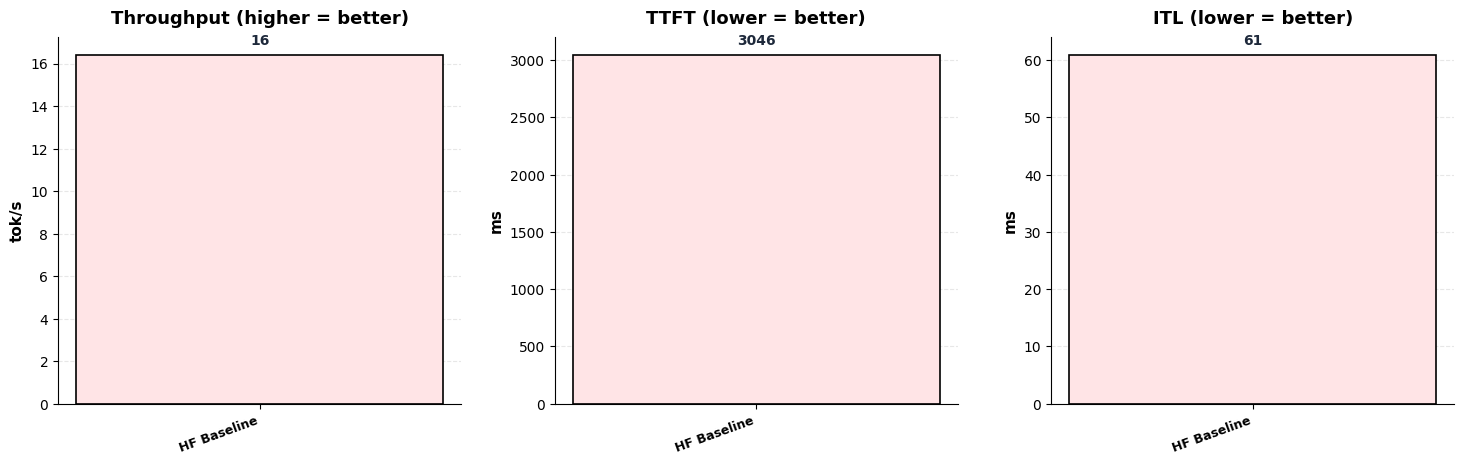

In [6]:
plot_running_comparison()

## Config 2: vLLM Default (PagedAttention + Continuous Batching)

vLLM is a production inference engine. Two core innovations are always on:

**PagedAttention:** Instead of pre-allocating contiguous memory for each request's KV cache
(which wastes 50-70% due to fragmentation), vLLM uses a page table. KV blocks are stored
in non-contiguous pages, allocated on demand. No waste.

**Continuous Batching:** Traditional batching pads all sequences to the longest one and waits
for the entire batch to finish. vLLM schedules at the iteration level: when one request finishes,
its slot is immediately filled by the next. No padding waste, no idle GPU cycles.m

Together, these give 5-20x throughput improvement over naive HF serving.

**Start the server in terminal:**
```bash
python -m vllm.entrypoints.openai.api_server \
    --model mistralai/Mistral-7B-v0.1 \
    --dtype float16 \
    --no-enable-prefix-caching \
    --gpu-memory-utilization 0.80 \
    --port 8000
```

Wait for `Uvicorn running on http://0.0.0.0:8000` before running the next cell.


In [7]:
# --- vLLM Default ---
assert check_server()
warmup_server()

# Throughput + TTFT + ITL
vllm_metrics = benchmark_full(PROMPTS, max_tokens=N_TOKENS, n_workers=N_REQUESTS, label='vLLM')


# KV cache measurements
print('\nKV cache vs concurrent users (max_tokens=1000):')
vllm_kv_users = measure_kv_vs_users()
print('\nKV cache vs context length (up to 4096):')
vllm_kv_context = measure_kv_vs_context()

all_results['vLLM'] = {**vllm_metrics, 'kv_users': vllm_kv_users, 'kv_context': vllm_kv_context}
print(f'\nSpeedup over HF: {vllm_metrics["throughput"]/all_results["HF Baseline"]["throughput"]:.1f}x')


vLLM server running.
Warmup done (5 requests).


vLLM: 100%|██████████| 10/10 [00:03<00:00,  3.29it/s]


  [vLLM] 163 tok/s | TTFT: 142ms | ITL: 59.2ms

KV cache vs concurrent users (max_tokens=1000):


KV vs users:  20%|██        | 1/5 [00:56<03:45, 56.42s/it]

    1 users -> 0.7% KV


...

   1024 tokens -> 18.0% KV


KV vs context:  80%|████████  | 4/5 [02:11<00:33, 33.90s/it]

   2048 tokens -> 35.0% KV


KV vs context: 100%|██████████| 5/5 [02:55<00:00, 35.11s/it]

   4096 tokens -> 37.3% KV

Speedup over HF: 10.0x


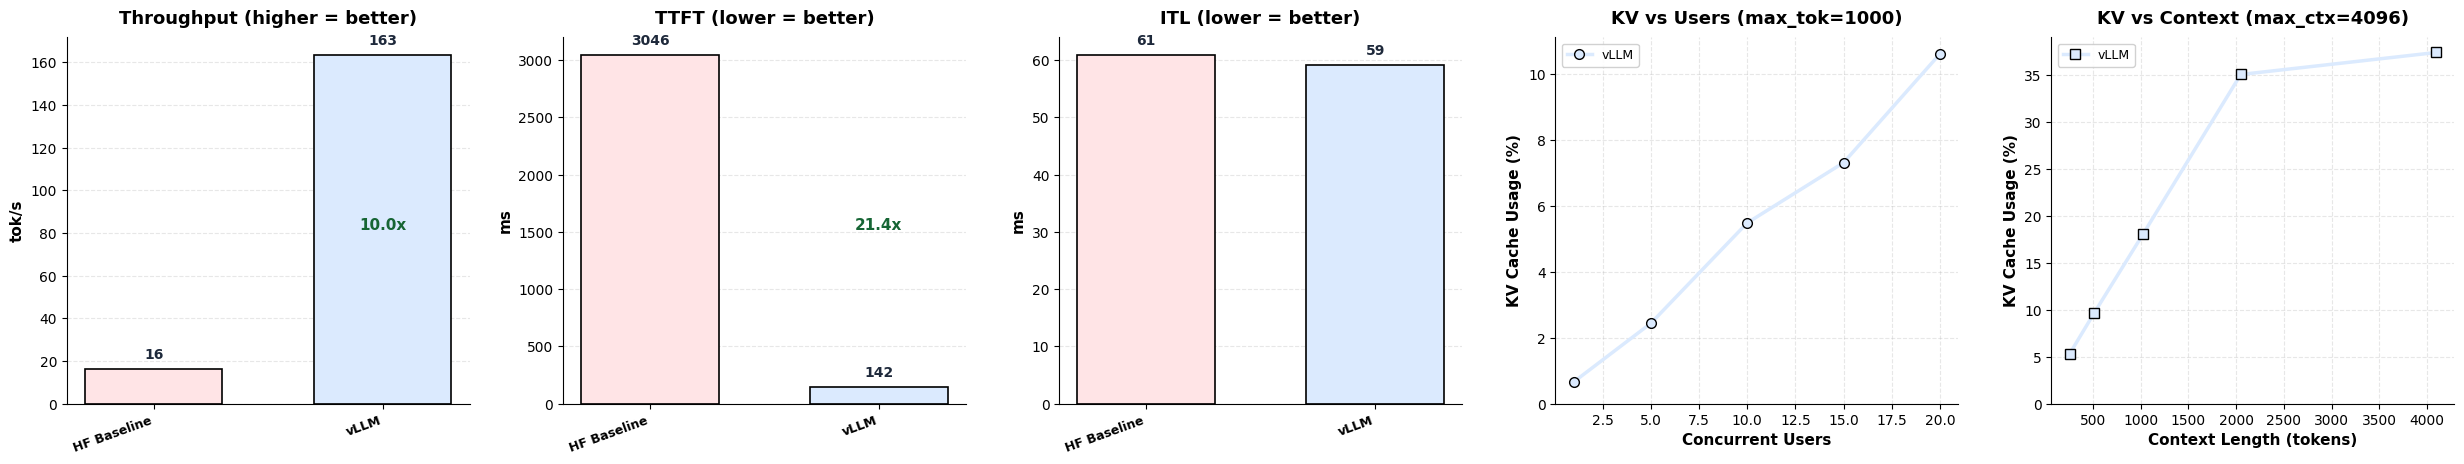

In [8]:
plot_running_comparison()

## Config 3: vLLM + Prefix Caching

Many LLM applications share a common prefix across requests:
- Chat apps: same system prompt for every user message
- RAG: same retrieved context for follow-up questions
- Few-shot: same examples prepended to every query

Without prefix caching, vLLM recomputes the KV cache for this shared prefix on EVERY request.
With `--enable-prefix-caching`, vLLM hashes token blocks and reuses cached KV values when
the same prefix appears again. First request pays full cost, subsequent requests skip the
shared prefix computation entirely.

**Expected impact:** TTFT drops significantly for requests with shared prefixes.
Throughput may also improve since less compute is wasted on redundant prefills.

**Stop the server (Ctrl+C) and restart with prefix caching:**
```bash
python -m vllm.entrypoints.openai.api_server \
    --model mistralai/Mistral-7B-v0.1 \
    --dtype float16 \
    --enable-prefix-caching \
    --gpu-memory-utilization 0.80 \
    --port 8000
```


In [9]:
# --- vLLM + Prefix Caching ---
assert check_server()
warmup_server()

prefix_metrics = benchmark_full(PROMPTS, max_tokens=N_TOKENS, n_workers=N_REQUESTS, label='vLLM+Prefix')

print('\nKV cache vs users:')
prefix_kv_users = measure_kv_vs_users()
print('\nKV cache vs context:')
prefix_kv_context = measure_kv_vs_context()

all_results['vLLM+Prefix'] = {**prefix_metrics, 'kv_users': prefix_kv_users, 'kv_context': prefix_kv_context}
print(f'\nSpeedup over HF: {prefix_metrics["throughput"]/all_results["HF Baseline"]["throughput"]:.1f}x')

vLLM server running.
Warmup done (5 requests).


vLLM+Prefix: 100%|██████████| 10/10 [00:03<00:00,  3.30it/s]


  [vLLM+Prefix] 164 tok/s | TTFT: 143ms | ITL: 59.0ms

KV cache vs users:


KV vs users:  20%|██        | 1/5 [00:56<03:45, 56.35s/it]

    1 users -> 0.7% KV


...

   1024 tokens -> 4.5% KV


KV vs context:  80%|████████  | 4/5 [02:05<00:32, 32.01s/it]

   2048 tokens -> 7.9% KV


KV vs context: 100%|██████████| 5/5 [02:43<00:00, 32.61s/it]

   4096 tokens -> 13.7% KV

Speedup over HF: 10.0x


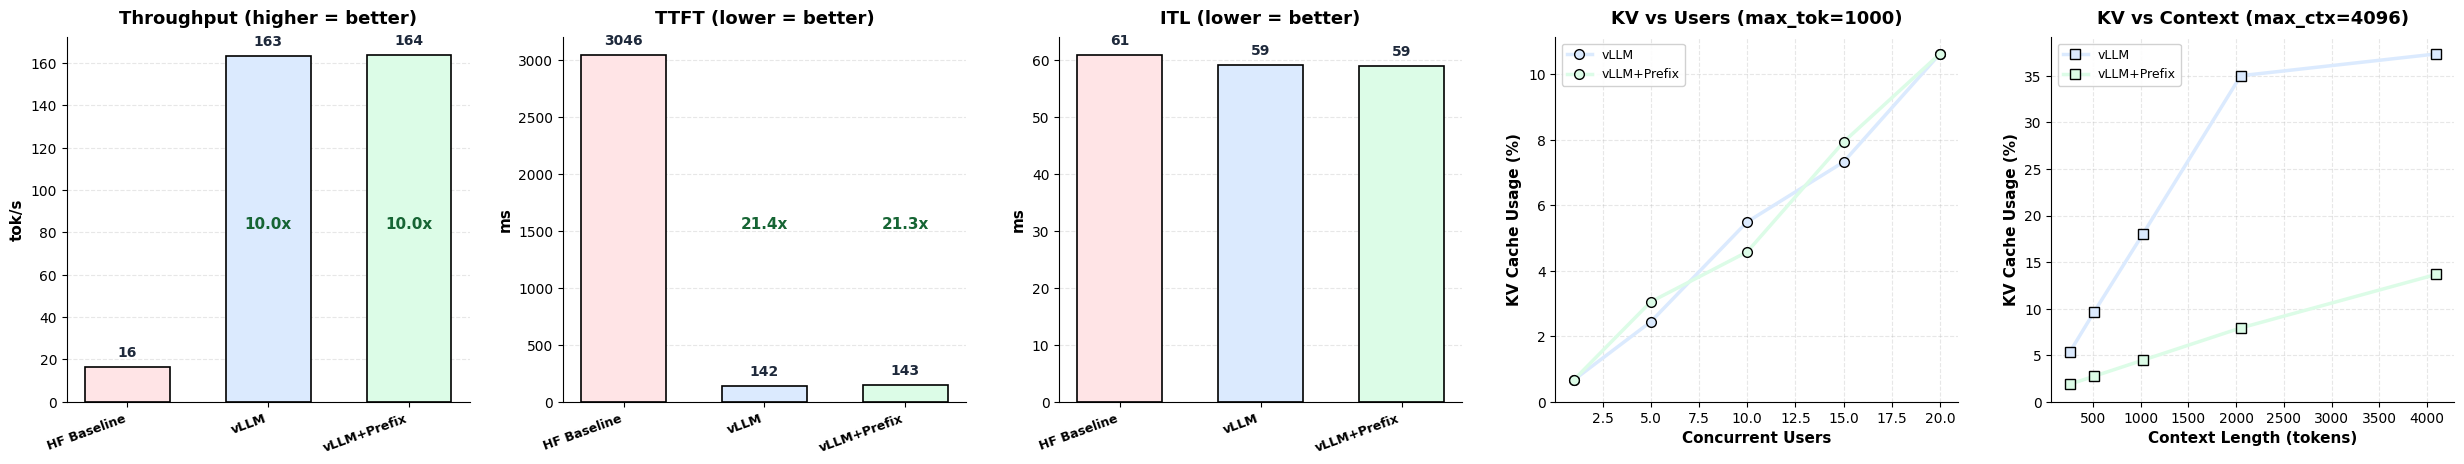

In [10]:
plot_running_comparison()

## Config 4: vLLM + Prefix + KV Quantization (FP8)

The KV cache stores attention keys and values for every token in every active request.
At FP16, each token costs 131 KB for Mistral-7B. With 100 concurrent users at 4K context,
that is 52 GB of KV cache alone.

**KV quantization** stores these values in FP8 (8-bit) instead of FP16 (16-bit).
This halves the memory per token, effectively doubling how many concurrent users fit
on the same GPU before OOM. The quality loss is minimal for most workloads.

**Expected impact:** KV cache grows ~50% slower with users/context. More users fit.
Throughput stays similar or improves (more headroom for batching).

**Stop the server and restart with FP8 KV cache:**
```bash
python -m vllm.entrypoints.openai.api_server \
    --model mistralai/Mistral-7B-v0.1 \
    --dtype float16 \
    --enable-prefix-caching \
    --kv-cache-dtype fp8 \
    --gpu-memory-utilization 0.80 \
    --port 8000
```


In [12]:
# --- vLLM + Prefix + KV Quant ---
assert check_server()
warmup_server()

kvq_metrics = benchmark_full(PROMPTS, max_tokens=N_TOKENS, n_workers=N_REQUESTS, label='vLLM+Prefix+KVQ')

print('\nKV cache vs users:')
kvq_kv_users = measure_kv_vs_users()
print('\nKV cache vs context:')
kvq_kv_context = measure_kv_vs_context()

all_results['vLLM+Prefix+KVQ'] = {**kvq_metrics, 'kv_users': kvq_kv_users, 'kv_context': kvq_kv_context}
print(f'\nSpeedup over HF: {kvq_metrics["throughput"]/all_results["HF Baseline"]["throughput"]:.1f}x')


vLLM server running.
Warmup done (5 requests).


vLLM+Prefix+KVQ: 100%|██████████| 10/10 [00:03<00:00,  3.27it/s]


  [vLLM+Prefix+KVQ] 162 tok/s | TTFT: 158ms | ITL: 59.3ms

KV cache vs users:


KV vs users:  20%|██        | 1/5 [00:54<03:38, 54.74s/it]

    1 users -> 0.3% KV


...

   1024 tokens -> 2.3% KV


KV vs context:  80%|████████  | 4/5 [02:00<00:30, 30.15s/it]

   2048 tokens -> 4.0% KV


KV vs context: 100%|██████████| 5/5 [02:31<00:00, 30.30s/it]

   4096 tokens -> 7.0% KV

Speedup over HF: 9.9x


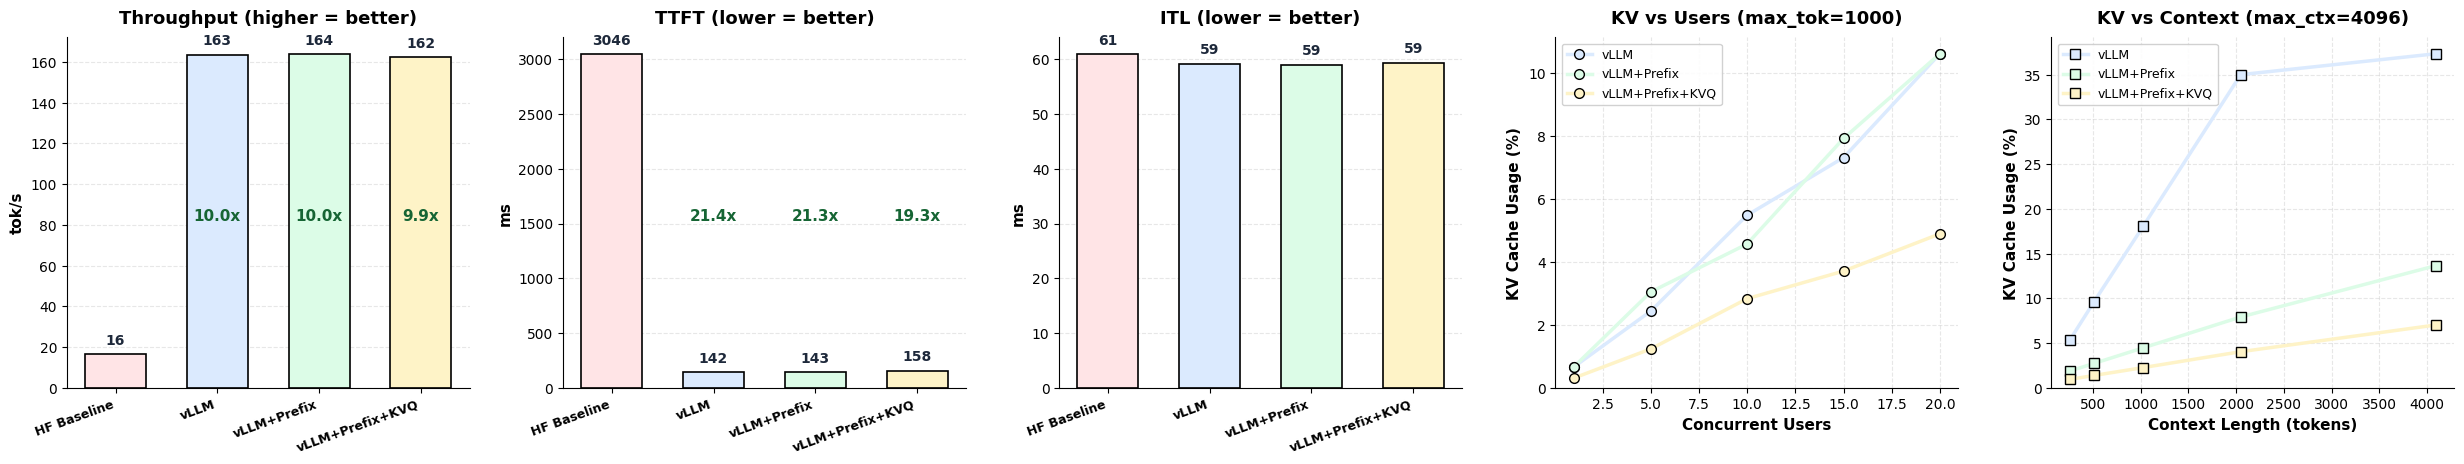

In [13]:
plot_running_comparison()

## Config 5: vLLM + Prefix + KV Quant + Speculative Decoding (ngram)

Autoregressive decoding is inherently sequential: each token depends on the previous.
Speculative decoding breaks this by using a cheap method to GUESS multiple tokens ahead,
then the main model verifies them all in one parallel forward pass.

**ngram speculation:** Instead of a separate draft model (which needs matching vocabulary),
ngram uses patterns from the prompt itself to predict next tokens. Zero extra model weight,
zero compatibility issues. Works best for repetitive/structured outputs.

**Expected impact:** ITL (inter-token latency) drops when speculation hits. But for diverse,
unpredictable outputs (like our test prompts), the overhead of failed speculations can
actually REDUCE throughput. This is the honest tradeoff.

**Stop the server and restart with all flags:**
```bash
python -m vllm.entrypoints.openai.api_server \
    --model mistralai/Mistral-7B-v0.1 \
    --dtype float16 \
    --enable-prefix-caching \
    --kv-cache-dtype fp8 \
    --spec-method ngram \
    --spec-tokens 5 \
    --gpu-memory-utilization 0.90 \
    --port 8000
```


In [14]:
# --- vLLM + All (Speculative ngram) ---
try:
    assert check_server()
    warmup_server()

    spec_metrics = benchmark_full(PROMPTS, max_tokens=N_TOKENS, n_workers=N_REQUESTS, label='vLLM+All')
    
    print('\nKV cache vs users:')
    spec_kv_users = measure_kv_vs_users()
    print('\nKV cache vs context:')
    spec_kv_context = measure_kv_vs_context()

    all_results['vLLM+All'] = {**spec_metrics, 'kv_users': spec_kv_users, 'kv_context': spec_kv_context}
    print(f'\nSpeedup over HF: {spec_metrics["throughput"]/all_results["HF Baseline"]["throughput"]:.1f}x')
except Exception as e:
    print(f'Speculative failed: {e}')
    all_results['vLLM+All'] = None


vLLM server running.
Warmup done (5 requests).


vLLM+All: 100%|██████████| 10/10 [00:03<00:00,  2.79it/s]


  [vLLM+All] 135 tok/s | TTFT: 148ms | ITL: 70.4ms

KV cache vs users:


KV vs users:  20%|██        | 1/5 [00:10<00:42, 10.55s/it]

    1 users -> 0.2% KV


...

   1024 tokens -> 2.4% KV


KV vs context:  80%|████████  | 4/5 [00:36<00:08,  8.25s/it]

   2048 tokens -> 3.7% KV


KV vs context: 100%|██████████| 5/5 [00:43<00:00,  8.69s/it]

   4096 tokens -> 5.3% KV

Speedup over HF: 8.2x


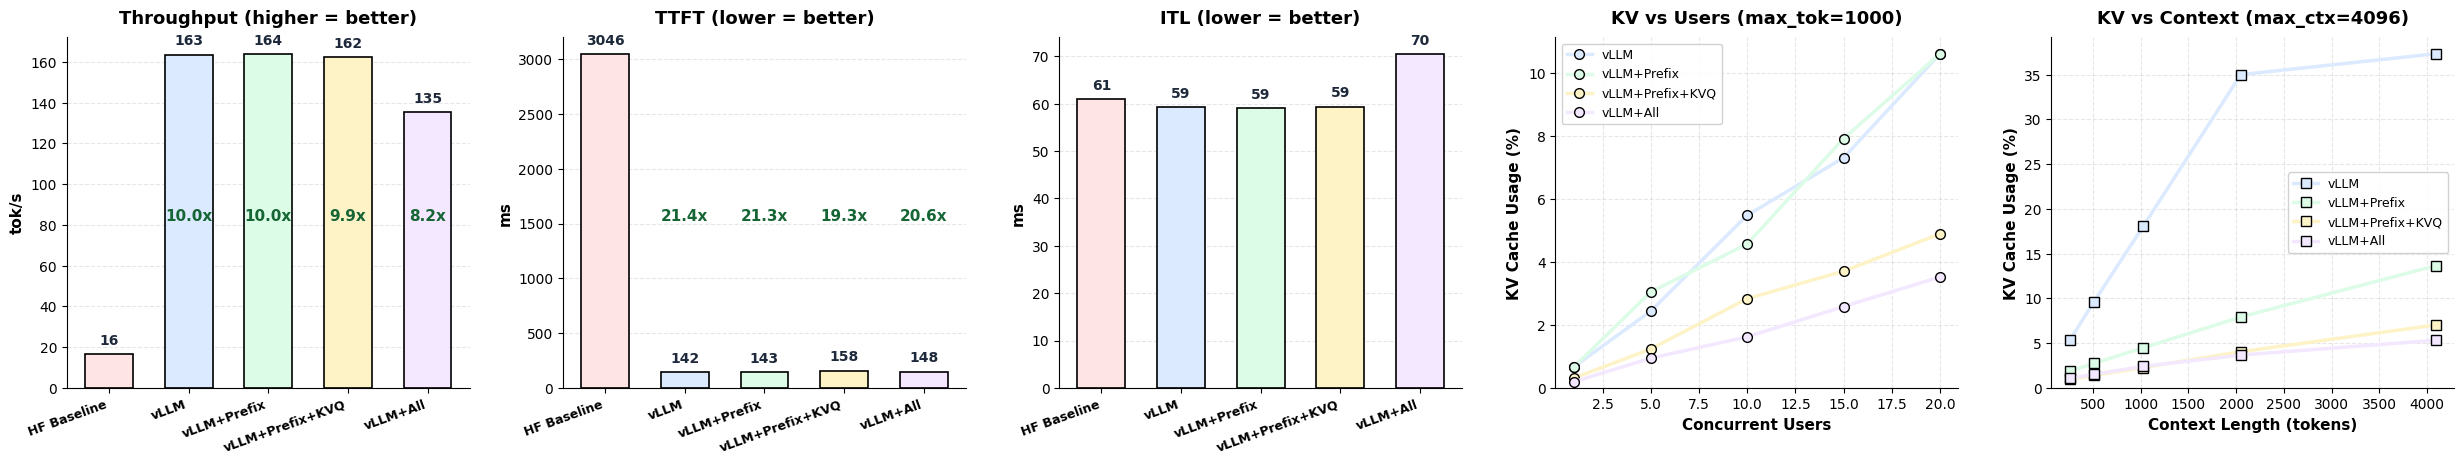

In [15]:
plot_running_comparison()

## Final Comparison: All Configs x All Metrics

Same model (Mistral-7B). Same GPU (A100). Same 10 prompts. Same 50 output tokens.
The ONLY variable is the server configuration. Each config stacks one more optimization.

The 6-panel chart below shows:
- **Top row:** Performance metrics (throughput, TTFT, ITL)
- **Bottom row:** Memory metrics (KV vs users, KV vs context) + cumulative speedup

**Key questions the chart answers:**
1. Which optimization gives the biggest throughput jump?
2. Does prefix caching reduce TTFT meaningfully?
3. Does KV quantization actually allow more concurrent users?
4. Does speculative decoding help or hurt for diverse prompts?


/tmp/ipykernel_171545/1658281751.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(configs, rotation=20, ha='right', fontsize=8)
/tmp/ipykernel_171545/1658281751.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(configs, rotation=20, ha='right', fontsize=8)
/tmp/ipykernel_171545/1658281751.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(configs, rotation=20, ha='right', fontsize=8)
/tmp/ipykernel_171545/1658281751.py:83: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(configs, rotation=20, ha='right', fontsize=8)


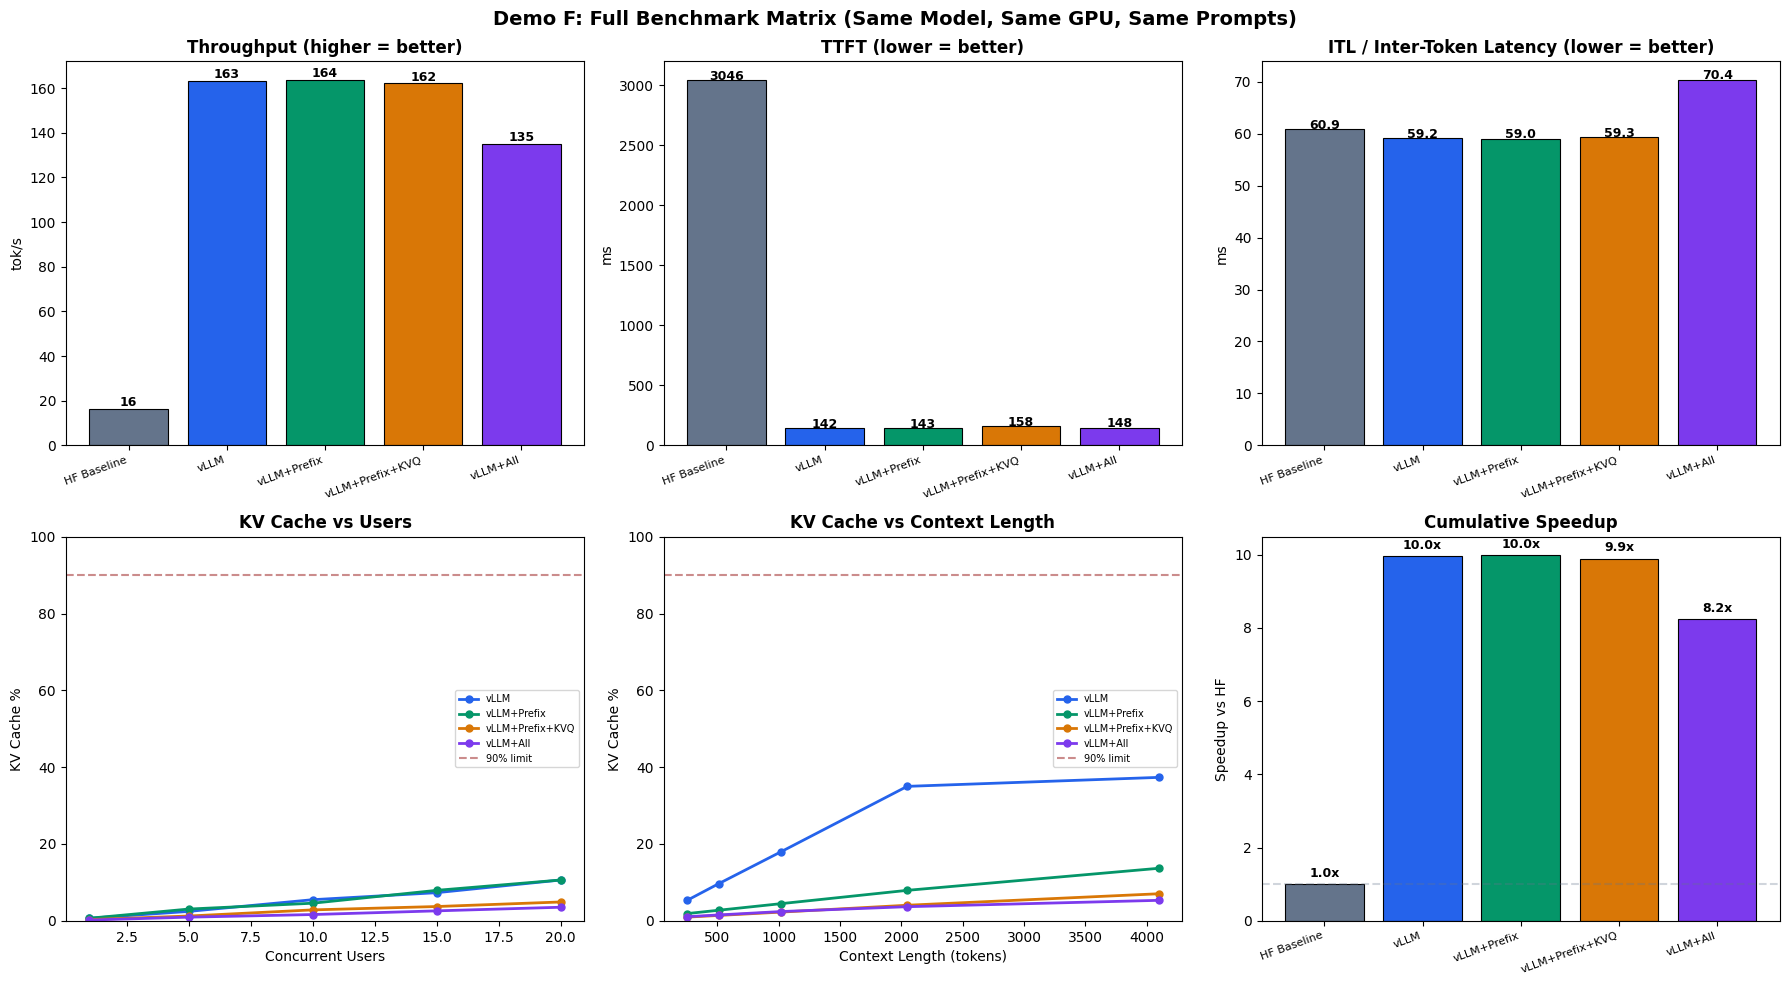


Config                    tok/s  TTFT ms   ITL ms    vs HF
----------------------------------------------------------------------
HF Baseline                  16     3046     60.9     1.0x
vLLM                        163      142     59.2    10.0x
vLLM+Prefix                 164      143     59.0    10.0x
vLLM+Prefix+KVQ             162      158     59.3     9.9x
vLLM+All                    135      148     70.4     8.2x


In [16]:
# --- Final Multi-Panel Comparison ---
valid = {k: v for k, v in all_results.items() if v is not None}
configs = list(valid.keys())
colors = ['#64748b', '#2563eb', '#059669', '#d97706', '#7c3aed'][:len(configs)]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# --- Row 1: Throughput, TTFT, ITL ---
# Throughput
ax = axes[0, 0]
tps = [valid[c]['throughput'] for c in configs]
bars = ax.bar(configs, tps, color=colors, edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, tps):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.0f}',
            ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('tok/s')
ax.set_title('Throughput (higher = better)', fontweight='bold')
ax.set_xticklabels(configs, rotation=20, ha='right', fontsize=8)

# TTFT
ax = axes[0, 1]
ttfts = [valid[c]['ttft'] * 1000 for c in configs]
bars = ax.bar(configs, ttfts, color=colors, edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, ttfts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.0f}',
            ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('ms')
ax.set_title('TTFT (lower = better)', fontweight='bold')
ax.set_xticklabels(configs, rotation=20, ha='right', fontsize=8)

# ITL
ax = axes[0, 2]
itls = [valid[c]['itl'] * 1000 for c in configs]
bars = ax.bar(configs, itls, color=colors, edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, itls):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{val:.1f}',
            ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('ms')
ax.set_title('ITL / Inter-Token Latency (lower = better)', fontweight='bold')
ax.set_xticklabels(configs, rotation=20, ha='right', fontsize=8)

# --- Row 2: KV cache growth charts ---
# KV vs Users
ax = axes[1, 0]
for i, c in enumerate(configs):
    kv = valid[c].get('kv_users')
    if kv:
        users = [x[0] for x in kv]
        pcts = [x[1] for x in kv]
        ax.plot(users, pcts, 'o-', color=colors[i], label=c, linewidth=2, markersize=5)
ax.axhline(y=90, color='#991b1b', linestyle='--', alpha=0.5, label='90% limit')
ax.set_xlabel('Concurrent Users')
ax.set_ylabel('KV Cache %')
ax.set_title('KV Cache vs Users', fontweight='bold')
ax.set_ylim(0, 100)
ax.legend(fontsize=7)

# KV vs Context
ax = axes[1, 1]
for i, c in enumerate(configs):
    kv = valid[c].get('kv_context')
    if kv:
        ctx = [x[0] for x in kv]
        pcts = [x[1] for x in kv]
        ax.plot(ctx, pcts, 'o-', color=colors[i], label=c, linewidth=2, markersize=5)
ax.axhline(y=90, color='#991b1b', linestyle='--', alpha=0.5, label='90% limit')
ax.set_xlabel('Context Length (tokens)')
ax.set_ylabel('KV Cache %')
ax.set_title('KV Cache vs Context Length', fontweight='bold')
ax.set_ylim(0, 100)
ax.legend(fontsize=7)

# Speedup summary
ax = axes[1, 2]
hf_tps = valid['HF Baseline']['throughput']
speedups = [valid[c]['throughput'] / hf_tps for c in configs]
bars = ax.bar(configs, speedups, color=colors, edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, speedups):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f'{val:.1f}x',
            ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('Speedup vs HF')
ax.set_title('Cumulative Speedup', fontweight='bold')
ax.set_xticklabels(configs, rotation=20, ha='right', fontsize=8)
ax.axhline(y=1, color='#64748b', linestyle='--', alpha=0.3)

plt.suptitle('Demo F: Full Benchmark Matrix (Same Model, Same GPU, Same Prompts)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('demo_f_full_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print table
print('\n' + '='*70)
print(f'{"Config":<22} {"tok/s":>8} {"TTFT ms":>8} {"ITL ms":>8} {"vs HF":>8}')
print('-'*70)
for c in configs:
    r = valid[c]
    print(f"{c:<22} {r["throughput"]:>8.0f} {r["ttft"]*1000:>8.0f} {r["itl"]*1000:>8.1f} {r["throughput"]/hf_tps:>7.1f}x")
print('='*70)


## Summary

| Config | Best For |
|---|---|
| vLLM default | General serving (PagedAttention + batching always on) |
| + Prefix caching | Chat/RAG with shared system prompts |
| + KV quantization | High concurrency, long contexts (2x memory capacity) |
| + Speculative (ngram) | Repetitive/structured outputs (hurts diverse prompts) |

**Key insight:** Not every optimization helps every workload.
The peak (prefix + KV quant) gives the best stacked improvement for diverse prompts.
Speculative decoding needs same-family model pairs to shine.

**Next:** Demo G tests SGLang's RadixAttention for superior partial-prefix matching.
